Практическая работа 2 Рюмина 09.07.14п2

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

ЗАДАНИЕ 1

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

Подключаем библиотеки и загружаем датасет

In [3]:
df = pd.read_csv('/content/train.csv')

ЗАДАНИЕ 2

Выводим количество строк и столбцов

In [6]:
df.shape

(891, 12)

Вывели названия всех столбцов

In [7]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

Выводим типы данных столбцов

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


ЗАДАНИЕ 3

Определяем количество пассажиров каждого класса

In [10]:
df['Pclass'].value_counts().sort_index()

,count
Pclass,
1,216
2,184
3,491


Определяем количество мужчин и женщин

In [12]:
df['Sex'].value_counts()

,count
Sex,
male,577
female,314


Разделяем пассажиров на возрастные группы

In [13]:
bins = [0, 12, 18, 30, 50, 100]
labels = ['ребёнок (0-12)', 'подросток (13-18)', 'молодой (19-30)',
          'взрослый (31-50)', 'пожилой (51+)']
df['AgeGroup'] = pd.cut(df['Age'], bins=bins, labels=labels)
print("\nВозрастные группы:")
df['AgeGroup'].value_counts().sort_index()


Возрастные группы:


,count
AgeGroup,
ребёнок (0-12),69
подросток (13-18),70
молодой (19-30),270
взрослый (31-50),241
пожилой (51+),64


Определяем средний возраст пассажиров

In [14]:
df['Age'].mean()

np.float64(29.69911764705882)

Определяем медианный возраст

In [15]:
df['Age'].median()

28.0

Определяем среднюю стоимость билета

In [16]:
df['Fare'].mean()

np.float64(32.204207968574636)

ЗАДАНИЕ 4

Сравним стоимость билета для 1, 2 и 3 классов

In [17]:
df.groupby('Pclass')['Fare'].mean().round(2)

,Fare
Pclass,
1,84.15
2,20.66
3,13.68


Сравним средний возраст пассажиров разных классов

In [18]:
df.groupby('Pclass')['Age'].mean().round(2)

,Age
Pclass,
1,38.23
2,29.88
3,25.14


Сравним количество мужчин и женщин в каждом классе

In [19]:
df.groupby(['Pclass', 'Sex']).size().unstack()

Sex,female,male
Pclass,,
1,94,122
2,76,108
3,144,347


Определим, в каком классе было больше всего пассажиров

In [20]:
df['Pclass'].value_counts().idxmax()

np.int64(3)

Билеты в 1 класс значительно дороже чем в 2 и 3, примерно в 4 раза. Так же возраст в 1 классе больше примерно на 10 лет. Мужчин больше всего в 3 классе, женщин так же в 3. Меньше всего мужчин во 2 классе, меньше всего женщин так же во 2.

Найдем самый дорогой билет, определив при этом класс, возраст, пол и факт выживания

In [21]:
max_fare_row = df.loc[df['Fare'].idxmax()]
print("\nСамый дорогой билет:")
print(max_fare_row[['PassengerId', 'Pclass', 'Name', 'Sex', 'Age',
                    'Fare', 'Survived']])


Самый дорогой билет:
PassengerId                 259
Pclass                        1
Name           Ward, Miss. Anna
Sex                      female
Age                        35.0
Fare                   512.3292
Survived                      1
Name: 258, dtype: object


ЗАДАНИЕ 5

Определим общее количество выживших и погибших. Погибших 549, выживших 342

In [23]:
df['Survived'].value_counts()

,count
Survived,
0,549
1,342


Сравним выживаемость мужчин и женщин. У женщин выживаемость больше

In [24]:
df.groupby('Sex')['Survived'].mean().round(3)

,Survived
Sex,
female,0.742
male,0.189


Сравним выживаемость мужчин и женщин для каждого класса

In [25]:
df.groupby(['Pclass', 'Sex'])['Survived'].mean().round(3).unstack()

Sex,female,male
Pclass,,
1,0.968,0.369
2,0.921,0.157
3,0.500,0.135


Определим, какая группа пассажиров имела наибольшую долю выживших

In [27]:
surv_by_class_sex = df.groupby(['Pclass', 'Sex'])['Survived'].mean()
best = surv_by_class_sex.idxmax()
print(f"\nНаибольшая доля выживших: класс {best[0]}, пол {best[1]} "
      f"({surv_by_class_sex.max():.3f})")


Наибольшая доля выживших: класс 1, пол female (0.968)


ЗАДАНИЕ 6

Построим график количества пассажиров по классам

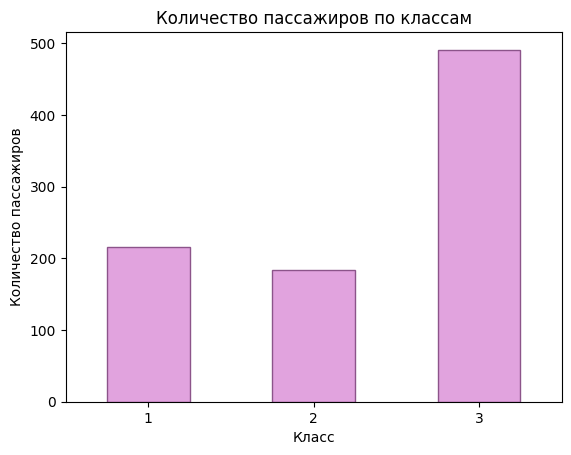

In [30]:
df['Pclass'].value_counts().sort_index().plot(
    kind='bar', color='#e1a3de', edgecolor='#8c548a')
plt.title('Количество пассажиров по классам')
plt.xlabel('Класс')
plt.ylabel('Количество пассажиров')
plt.xticks(rotation=0)
plt.show()

Построим график выживаемости по полу

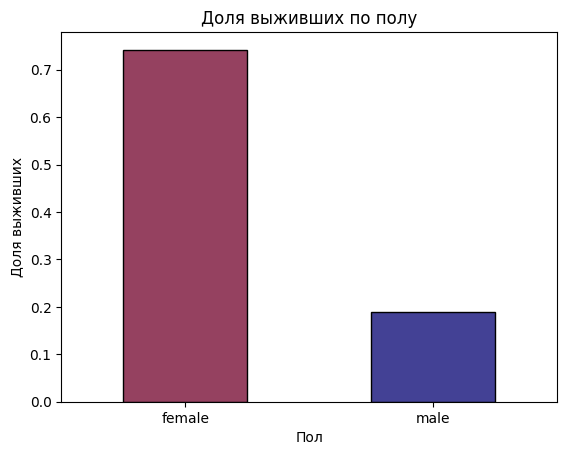

In [33]:
df.groupby('Sex')['Survived'].mean().plot(
    kind='bar', color=['#954160', '#434195'], edgecolor='black')
plt.title('Доля выживших по полу')
plt.xlabel('Пол')
plt.ylabel('Доля выживших')
plt.xticks(rotation=0)
plt.show()

В каком классе разрыв в выживаемости между женщинами и мужчинами самый большой и почему?

 Самый большой разрыв — во 2 классе (0.764). Женщины 2 класса выживали почти так же часто, как женщины 1 класса (92%), а мужчины 2 класса — реже мужчин 1 и даже 3 класса (15.7%).

Во 2 классе мужчин было 108, женщин 76 — конкуренция за шлюпки среди мужчин высокая, а экипаж забирал в первую очередь женщин. В 1 классе часть мужчин попала в шлюпки как гребцы, поэтому их выживаемость выше. В 3 классе разрыв меньше, потому что женщины там тоже массово гибли (50%) — их было много и они были далеко от шлюпок.